# CDS (ERA5-Land) vs JMA Station Comparison

Sense-checks the gridded ERA5-Land reanalysis (notebook 01) against the observed JMA station record (notebook 02) at the three comparable point locations -- Tokyo, Osaka, Nagoya. This is groundwork, not one of the three RQs: the goal is a defensible statement of which ERA5-Land metrics are trustworthy for absolute counts (e.g. RQ1's >=35C day counts) versus spatial-trend-only, closing out the validation question flagged after notebook 02 (ERA5-Land's cold bias visibly undercounts hot days there, but wasn't quantified station-by-station).

## Background: Why We Don't Expect Close Agreement

ERA5-Land and JMA are not two measurements of the same thing -- they are different kinds of data, and the mismatch quantified below is expected, not itself evidence that either dataset is wrong.

- **ERA5-Land is a reanalysis, not an observation.** It is a physically-consistent, model-generated reconstruction that assimilates whatever observations are available, produced on a 0.1° (~9-11km) grid. Each grid-cell value is an area-average over that cell -- roughly its terrain, land use, and coastal proximity averaged together -- not a reading at a specific point.
- **JMA station data is a direct instrument measurement at one fixed point**, and all three stations here were deliberately chosen as urban built-environment sites, not incidentally -- each sits in a dense metropolitan core. Urban heat-island warming at that exact point is real and physically driven by built surfaces (asphalt, concrete, building mass) retaining and re-radiating heat in ways a land-surface model's parameterization does not fully resolve at 0.1° resolution; a grid-cell average diluted with surrounding less-built terrain will not reproduce it. Because all three stations share this urban characteristic by design, this predicts a *similar-magnitude* bias across Tokyo/Osaka/Nagoya rather than one station standing out as an outlier -- consistent with Section 2's numbers, where the Tmax/Tmin bias sits in a tight band across all three stations with no clear exception.
- **Precipitation character differs by season, and that affects how localised the point-vs-grid mismatch is.** Baiu-season rain (Jun-Jul) is produced by a quasi-stationary frontal band -- broader-scale and more stratiform-leaning than a simple afternoon thunderstorm -- but it is not purely stratiform either: mesoscale convective systems embedded within the Baiu front are a well-documented source of its heaviest, most localised rainfall. The post-Baiu heat season (Jul-Sep) leans further toward discrete, highly localised convective cells (afternoon thunderstorms, occasional typhoon-related bursts). Either way, a station can record a heavy shower that falls entirely within one grid-cell's sub-area, or miss one that the grid-cell average partially captures -- weaker agreement here than for temperature is expected for this reason, not a sign of a data problem.

Given this, the useful question is not "do the two datasets match" -- they should not be expected to, at the single-point level this notebook tests. The useful questions are: (1) **is the bias systematic and consistent** (same sign, similar magnitude, across stations and over time) rather than random noise, and (2) **does ERA5-Land still track the right temporal dynamics** (year-to-year variability, extreme events) even where its absolute level is offset. A consistent, well-behaved bias is something RQ1/RQ2 can work around (e.g. trend-only use); an inconsistent or sign-flipping one would be a much bigger problem. Sections 1-5 test exactly this.

## Setup

Repo-root discovery, `figures/` output directory, and station display conventions shared with notebook 02 (same three stations, same colors). This notebook does plain descriptive statistics only (bias, RMSE, Pearson r) -- it is validation/exploration, not one of the three RQs, so the bootstrap-CI/permutation-test machinery reserved for the RQ1-3 statistical analysis does not apply here.

In [1]:
%matplotlib inline

import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

_p = pathlib.Path.cwd()
while not (_p / ".git").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

from src.jma_data import load_stations, station_metadata

NOTEBOOK_ID = "03"
NOTEBOOK_NAME = "03_cds_jma_comparison"
FIGURES_DIR = _p / "figures" / NOTEBOOK_NAME
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, section, fig_num, title: str) -> None:
    """Save *fig* to figures/<notebook>/ using the project convention [NB]_[section]-[fig#]_[title].png."""
    fig.savefig(FIGURES_DIR / f"{NOTEBOOK_ID}_{section}-{fig_num}_{title}.png", dpi=150, bbox_inches="tight")


# Same three stations, same colors as notebook 02 -- Sapporo/Fukuoka are out of scope
# (out-of-region sanity checks were considered and dropped; Tokyo/Osaka/Nagoya keeps this
# notebook aligned with notebook 02's scope).
STATIONS = ["tokyo", "osaka", "nagoya"]
STATION_LABELS = {"tokyo": "Tokyo", "osaka": "Osaka", "nagoya": "Nagoya"}
STATION_COLORS = {"tokyo": "tab:red", "osaka": "tab:blue", "nagoya": "tab:green"}

REPRESENTATIVE_YEAR = 2018  # record Kumagaya 41.1C heat wave; also a notable Baiu year

## Data Processing

Builds one tidy DataFrame with a row per station-day, holding both the ERA5-Land value at the **nearest grid cell** to the station and the JMA observed value, for Tmax, Tmin, and precipitation. Nearest-cell (not an area-mean) is used uniformly for all three stations -- an area-mean would conflate spatial averaging with the point-validation this notebook is for; area-mean is reserved for the separate Kanto-region trend analysis.

**JMA station coordinates** (from `data/jma/master_receipt.json`, via `src.jma_data.station_metadata`) -- the exact lat/lon each station's ERA5-Land nearest-cell is matched against:
- Tokyo: 35.6833°N, 139.7500°E
- Osaka: 34.6833°N, 135.5167°E
- Nagoya: 35.1667°N, 136.9667°E

ERA5-Land daily caches (`daily_max_t2m.nc`, `daily_min_t2m.nc`, `daily_tp.nc`) already exist from notebook 01 (JST-shifted, degC/mm) -- loaded directly here, no recomputation.

In [2]:
daily_tmax = xr.open_dataarray(_p / "data" / "processed" / "daily_max_t2m.nc").load()
daily_tmin = xr.open_dataarray(_p / "data" / "processed" / "daily_min_t2m.nc").load()
daily_tp = xr.open_dataarray(_p / "data" / "processed" / "daily_tp.nc").load()

jma = load_stations(STATIONS)

frames = []
for station in STATIONS:
    meta = station_metadata(station)
    lat, lon = meta["lat"], meta["lon"]

    cds_pt = pd.DataFrame(
        {
            "date": daily_tmax["valid_time"].values,
            "cds_tmax": daily_tmax.sel(latitude=lat, longitude=lon, method="nearest").values,
            "cds_tmin": daily_tmin.sel(latitude=lat, longitude=lon, method="nearest").values,
            "cds_precip": daily_tp.sel(latitude=lat, longitude=lon, method="nearest").values,
        }
    )
    cds_pt["date"] = pd.to_datetime(cds_pt["date"]).dt.normalize()

    jma_pt = jma.loc[
        jma["station"] == station, ["date", "max_temp", "min_temp", "precipitation", "rained"]
    ].rename(columns={"max_temp": "jma_tmax", "min_temp": "jma_tmin", "precipitation": "jma_precip"})

    merged = pd.merge(cds_pt, jma_pt, on="date", how="inner")
    merged.insert(0, "station", station)
    frames.append(merged)

combined = pd.concat(frames, ignore_index=True)
combined["year"] = combined["date"].dt.year
combined["month"] = combined["date"].dt.month

heat_season = combined[combined["month"].isin([7, 8, 9])].copy()  # Jul-Sep, RQ1 window
baiu_season = combined[combined["month"].isin([6, 7])].copy()  # Jun-Jul, RQ2 window
august = combined[combined["month"] == 8].copy()

combined.shape, combined["date"].min(), combined["date"].max()

C:\Users\dylan\anaconda3\envs\kanto-heat\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


((49311, 11),
 Timestamp('1980-01-01 00:00:00'),
 Timestamp('2024-12-31 00:00:00'))

## 1. Time-Series Overview (Qualitative)

A first visual gut-check before any bias/RMSE quantification: does ERA5-Land actually track the JMA station record over time, at both the seasonal-aggregate and daily scale? Purely descriptive -- the quantitative validation (scatter, bias, RMSE) follows in Sections 2-4.

### 1a. Annual August-Mean Tmax, CDS vs JMA

August daily-max temperature, averaged within each year, overlaid per station. Uses `august` from Data Processing above.

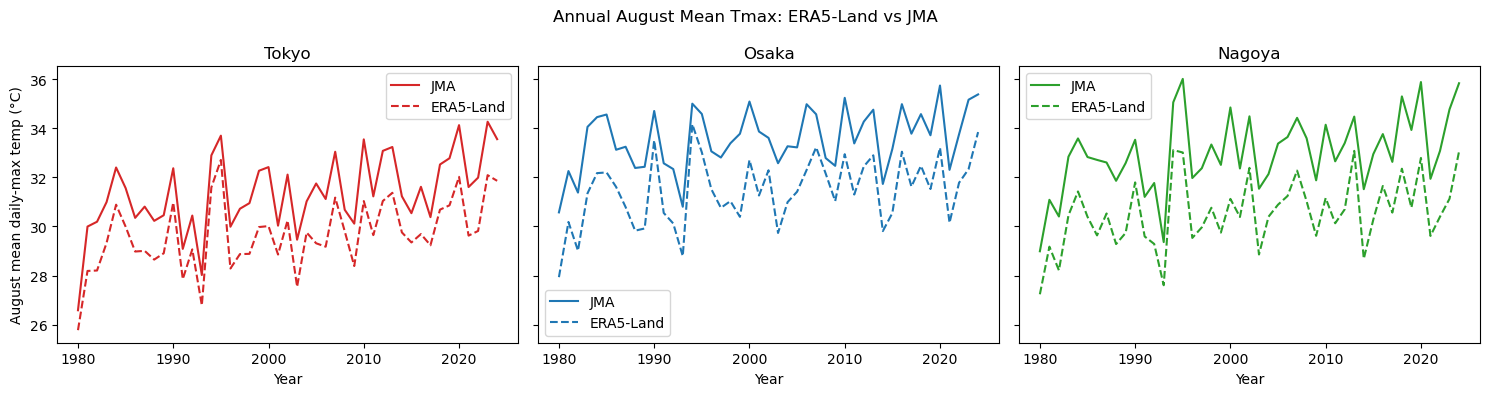

In [3]:
annual_aug_tmax = (
    august.groupby(["station", "year"])[["cds_tmax", "jma_tmax"]].mean().reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, station in zip(axes, STATIONS):
    sub = annual_aug_tmax[annual_aug_tmax["station"] == station]
    ax.plot(sub["year"], sub["jma_tmax"], color=STATION_COLORS[station], label="JMA")
    ax.plot(sub["year"], sub["cds_tmax"], color=STATION_COLORS[station], linestyle="--", label="ERA5-Land")
    ax.set_title(STATION_LABELS[station])
    ax.set_xlabel("Year")
    ax.legend()
axes[0].set_ylabel("August mean daily-max temp (°C)")
fig.suptitle("Annual August Mean Tmax: ERA5-Land vs JMA")
fig.tight_layout()
savefig(fig, 1, 1, "annual_aug_mean_tmax_cds_vs_jma")

### 1b. Annual Jun-Jul Total Precipitation, CDS vs JMA

Jun-Jul (Baiu window) total precipitation, per year, overlaid per station. Uses `baiu_season` from Data Processing above.

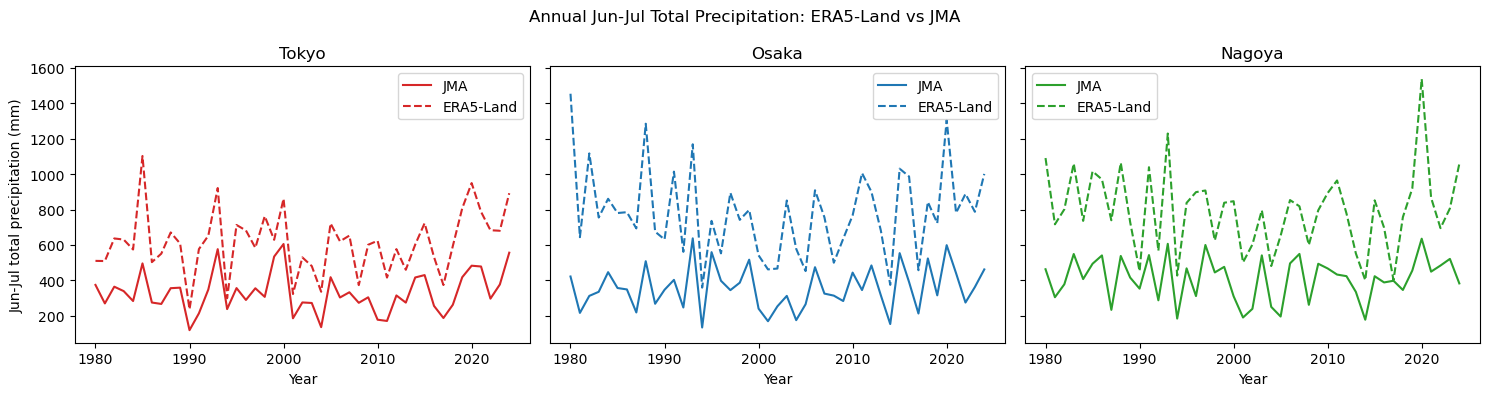

In [4]:
annual_jj_precip = (
    baiu_season.groupby(["station", "year"])[["cds_precip", "jma_precip"]].sum().reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, station in zip(axes, STATIONS):
    sub = annual_jj_precip[annual_jj_precip["station"] == station]
    ax.plot(sub["year"], sub["jma_precip"], color=STATION_COLORS[station], label="JMA")
    ax.plot(sub["year"], sub["cds_precip"], color=STATION_COLORS[station], linestyle="--", label="ERA5-Land")
    ax.set_title(STATION_LABELS[station])
    ax.set_xlabel("Year")
    ax.legend()
axes[0].set_ylabel("Jun-Jul total precipitation (mm)")
fig.suptitle("Annual Jun-Jul Total Precipitation: ERA5-Land vs JMA")
fig.tight_layout()
savefig(fig, 1, 2, "annual_jj_total_precip_cds_vs_jma")

### 1c. Daily Tracking, Representative Summer (2018)

Zoomed in to one representative season (Jun 1-Sep 30, 2018 -- the record Kumagaya 41.1C heat wave, also a notable Baiu year) to see day-to-day tracking rather than seasonal aggregates. Daily Tmax (top row) and daily precipitation (bottom row), per station.

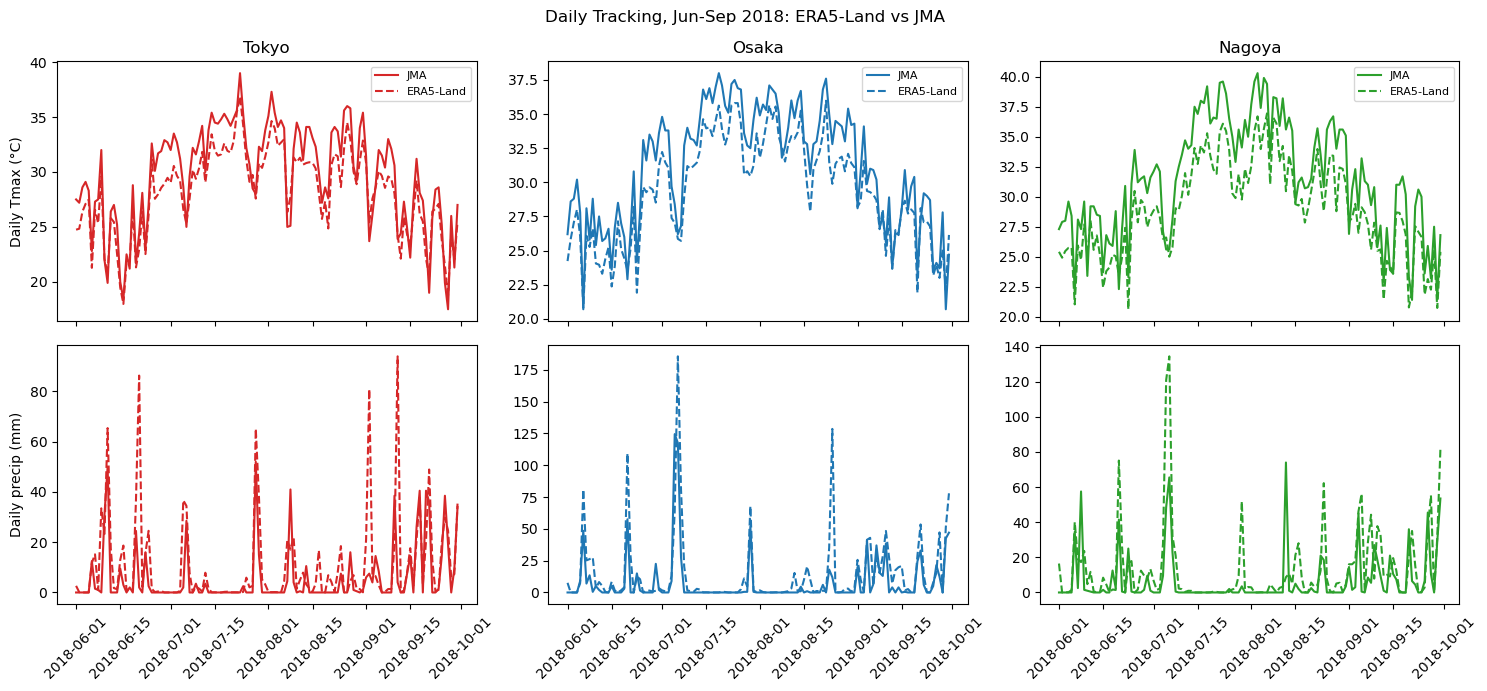

In [5]:
season_2018 = combined[
    (combined["date"] >= f"{REPRESENTATIVE_YEAR}-06-01") & (combined["date"] <= f"{REPRESENTATIVE_YEAR}-09-30")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for col, station in enumerate(STATIONS):
    sub = season_2018[season_2018["station"] == station]
    ax_t, ax_p = axes[0, col], axes[1, col]

    ax_t.plot(sub["date"], sub["jma_tmax"], color=STATION_COLORS[station], label="JMA")
    ax_t.plot(sub["date"], sub["cds_tmax"], color=STATION_COLORS[station], linestyle="--", label="ERA5-Land")
    ax_t.set_title(STATION_LABELS[station])
    ax_t.legend(fontsize=8)

    ax_p.plot(sub["date"], sub["jma_precip"], color=STATION_COLORS[station], label="JMA")
    ax_p.plot(sub["date"], sub["cds_precip"], color=STATION_COLORS[station], linestyle="--", label="ERA5-Land")
    ax_p.tick_params(axis="x", rotation=45)

axes[0, 0].set_ylabel("Daily Tmax (°C)")
axes[1, 0].set_ylabel("Daily precip (mm)")
fig.suptitle(f"Daily Tracking, Jun-Sep {REPRESENTATIVE_YEAR}: ERA5-Land vs JMA")
fig.tight_layout()
savefig(fig, 1, 3, f"daily_tracking_{REPRESENTATIVE_YEAR}_cds_vs_jma")

## 2. Temperature Validation (Quantitative)

Daily Tmax and Tmin, ERA5-Land nearest-cell vs JMA station, across the full 1980-2024 record (n=16,437 station-days each). Bias = mean(ERA5-Land - JMA); RMSE and Pearson r computed on the same paired daily series. Plain descriptive stats only, per Setup above -- no bootstrap CI here.

`stats_records` accumulates one row per station x variable across this section and Sections 3-4, feeding the Section 5 synthesis table without recomputing anything.

In [6]:
def bias_rmse_r(a: pd.Series, b: pd.Series) -> tuple[float, float, float]:
    """Bias (mean a-b), RMSE, and Pearson r between two paired daily series."""
    diff = a - b
    bias = diff.mean()
    rmse = np.sqrt((diff ** 2).mean())
    r = a.corr(b)
    return bias, rmse, r


stats_records = []


def scatter_1to1(ax, jma_vals, cds_vals, color, unit="°C"):
    """Shared scatter + 1:1 line + bias/RMSE/r title, used by every validation scatter below."""
    bias, rmse, r = bias_rmse_r(cds_vals, jma_vals)
    ax.scatter(jma_vals, cds_vals, s=2, alpha=0.15, color=color)
    lims = [min(jma_vals.min(), cds_vals.min()), max(jma_vals.max(), cds_vals.max())]
    ax.plot(lims, lims, color="black", linestyle=":", linewidth=1, label="1:1")
    ax.set_title(f"bias={bias:+.2f}{unit}, RMSE={rmse:.2f}{unit}, r={r:.3f}", fontsize=10)
    ax.legend(fontsize=8)
    return bias, rmse, r

### 2a. Daily Tmax

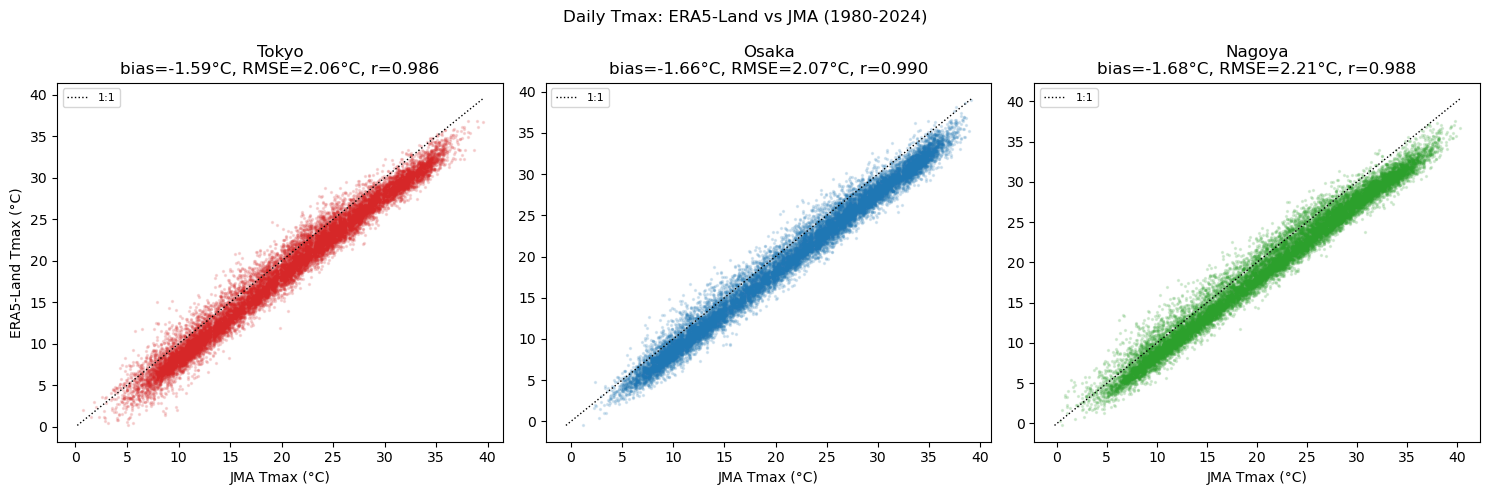

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, station in zip(axes, STATIONS):
    sub = combined[combined["station"] == station]
    bias, rmse, r = scatter_1to1(ax, sub["jma_tmax"], sub["cds_tmax"], STATION_COLORS[station])
    stats_records.append({"station": station, "variable": "tmax", "bias": bias, "rmse": rmse, "r": r, "n": len(sub)})
    ax.set_xlabel("JMA Tmax (°C)")

axes[0].set_ylabel("ERA5-Land Tmax (°C)")
for ax, station in zip(axes, STATIONS):
    ax.set_title(f"{STATION_LABELS[station]}\n" + ax.get_title())
fig.suptitle("Daily Tmax: ERA5-Land vs JMA (1980-2024)")
fig.tight_layout()
savefig(fig, 2, 1, "tmax_scatter_bias_cds_vs_jma")

### 2b. Daily Tmin

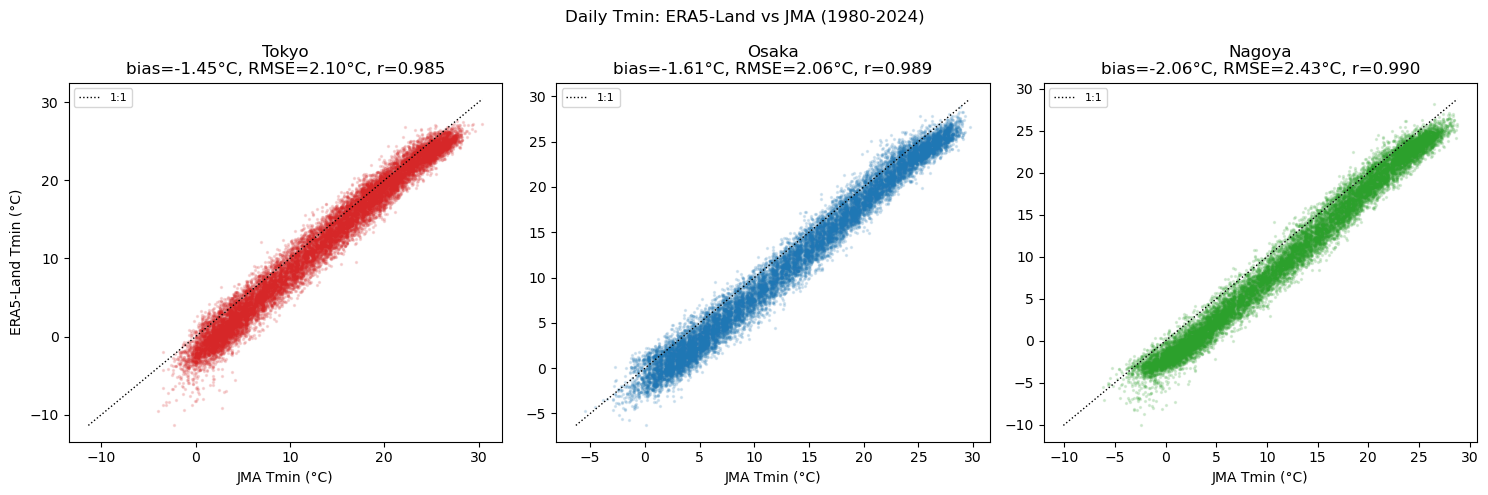

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, station in zip(axes, STATIONS):
    sub = combined[combined["station"] == station]
    bias, rmse, r = scatter_1to1(ax, sub["jma_tmin"], sub["cds_tmin"], STATION_COLORS[station])
    stats_records.append({"station": station, "variable": "tmin", "bias": bias, "rmse": rmse, "r": r, "n": len(sub)})
    ax.set_xlabel("JMA Tmin (°C)")

axes[0].set_ylabel("ERA5-Land Tmin (°C)")
for ax, station in zip(axes, STATIONS):
    ax.set_title(f"{STATION_LABELS[station]}\n" + ax.get_title())
fig.suptitle("Daily Tmin: ERA5-Land vs JMA (1980-2024)")
fig.tight_layout()
savefig(fig, 2, 2, "tmin_scatter_bias_cds_vs_jma")

## 3. Extreme Threshold Validation

Both RQ1 thresholds -- >=35°C extreme-heat days and >=25°C tropical nights, both Jul-Sep -- computed identically from ERA5-Land and JMA, compared per station per year. This quantifies the undercount notebook 02 flagged qualitatively (ERA5-Land's cold bias visibly suppressed hot-day counts there).

,cds_hot_day,jma_hot_day,cds_tropical_night,jma_tropical_night
station,,,,
nagoya,1.5,13.6,4.4,23.4
osaka,1.9,13.5,18.8,38.7
tokyo,0.6,5.0,11.2,28.6


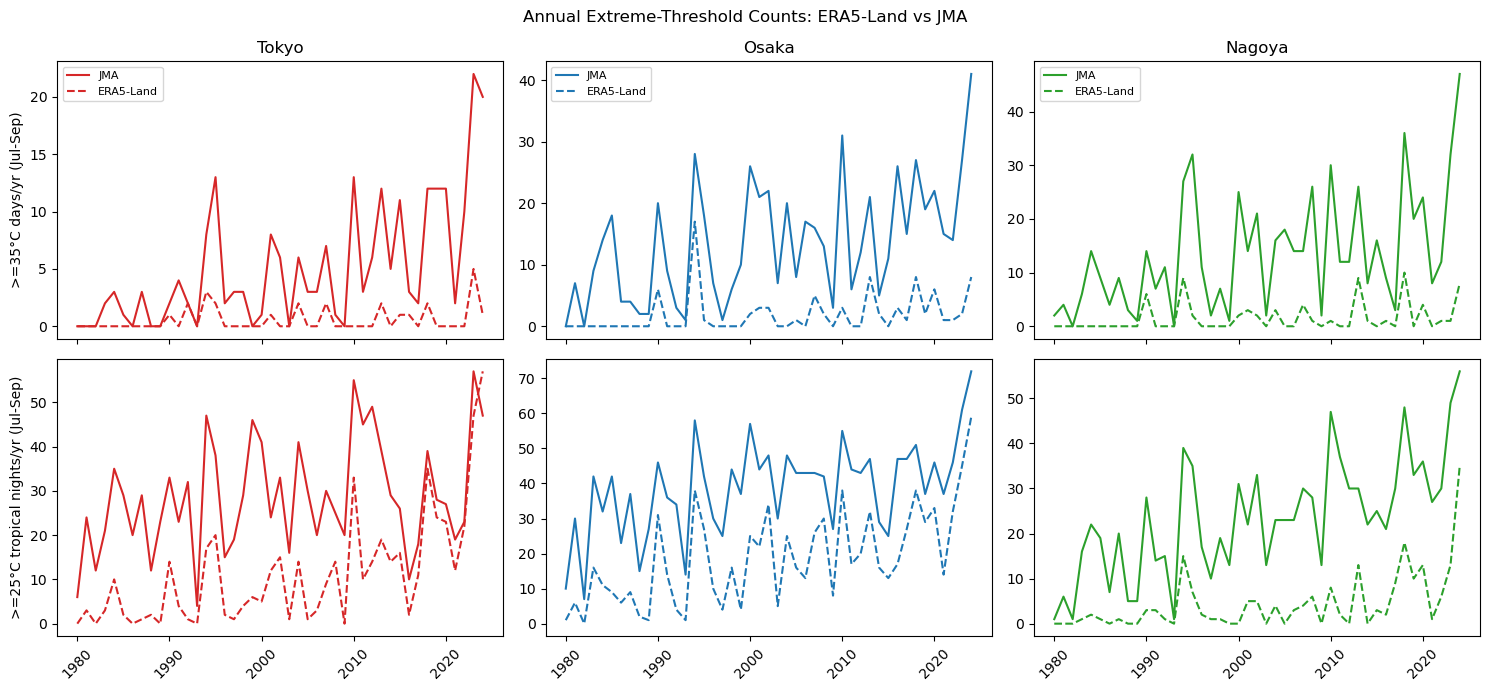

In [9]:
heat_season = heat_season.copy()
heat_season["cds_hot_day"] = heat_season["cds_tmax"] >= 35
heat_season["jma_hot_day"] = heat_season["jma_tmax"] >= 35
heat_season["cds_tropical_night"] = heat_season["cds_tmin"] >= 25
heat_season["jma_tropical_night"] = heat_season["jma_tmin"] >= 25

count_cols = ["cds_hot_day", "jma_hot_day", "cds_tropical_night", "jma_tropical_night"]
annual_extremes = heat_season.groupby(["station", "year"])[count_cols].sum().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for col, station in enumerate(STATIONS):
    sub = annual_extremes[annual_extremes["station"] == station]
    ax_hot, ax_night = axes[0, col], axes[1, col]

    ax_hot.plot(sub["year"], sub["jma_hot_day"], color=STATION_COLORS[station], label="JMA")
    ax_hot.plot(sub["year"], sub["cds_hot_day"], color=STATION_COLORS[station], linestyle="--", label="ERA5-Land")
    ax_hot.set_title(STATION_LABELS[station])
    ax_hot.legend(fontsize=8)

    ax_night.plot(sub["year"], sub["jma_tropical_night"], color=STATION_COLORS[station], label="JMA")
    ax_night.plot(sub["year"], sub["cds_tropical_night"], color=STATION_COLORS[station], linestyle="--", label="ERA5-Land")
    ax_night.tick_params(axis="x", rotation=45)

axes[0, 0].set_ylabel(">=35°C days/yr (Jul-Sep)")
axes[1, 0].set_ylabel(">=25°C tropical nights/yr (Jul-Sep)")
fig.suptitle("Annual Extreme-Threshold Counts: ERA5-Land vs JMA")
fig.tight_layout()
savefig(fig, 3, 1, "annual_extreme_threshold_counts_cds_vs_jma")

mean_annual_extremes = annual_extremes.groupby("station")[count_cols].mean().round(1)
mean_annual_extremes

## 4. Precipitation Validation (Quantitative)

Daily precipitation scatter (ERA5-Land nearest-cell vs JMA), plus wet-day agreement: does each dataset agree on which days it rained? JMA's `rained` flag (from the no-phenomenon code, distinguishing a true zero-rain day from a genuine no-precipitation day -- see `src/jma_data.py`) is compared against an ERA5-Land >=0.1mm threshold, a standard wet-day cutoff that avoids trace/rounding noise at exactly zero.

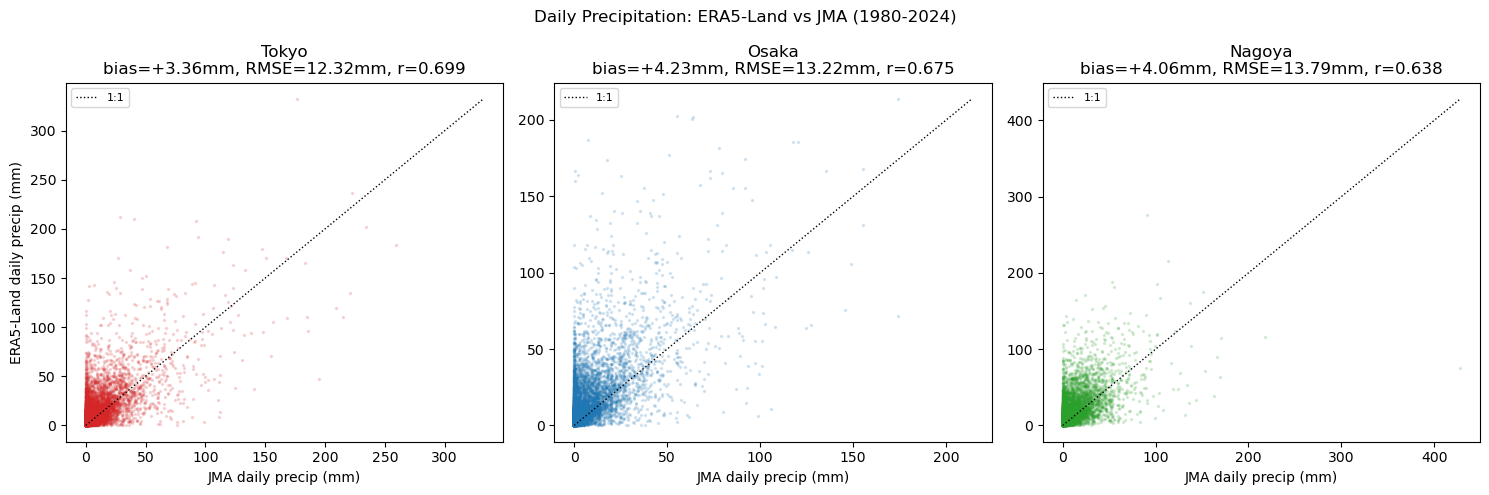

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, station in zip(axes, STATIONS):
    sub = combined[combined["station"] == station]
    bias, rmse, r = scatter_1to1(ax, sub["jma_precip"], sub["cds_precip"], STATION_COLORS[station], unit="mm")
    stats_records.append({"station": station, "variable": "precip", "bias": bias, "rmse": rmse, "r": r, "n": len(sub)})
    ax.set_xlabel("JMA daily precip (mm)")

axes[0].set_ylabel("ERA5-Land daily precip (mm)")
for ax, station in zip(axes, STATIONS):
    ax.set_title(f"{STATION_LABELS[station]}\n" + ax.get_title())
fig.suptitle("Daily Precipitation: ERA5-Land vs JMA (1980-2024)")
fig.tight_layout()
savefig(fig, 4, 1, "precip_scatter_bias_cds_vs_jma")

In [11]:
combined["cds_wet_day"] = combined["cds_precip"] >= 0.1
combined["agree"] = combined["cds_wet_day"] == combined["rained"]

wet_day_agreement = combined.groupby("station")["agree"].mean().round(3)
wet_day_agreement.rename("wet_day_agreement_rate").to_frame()

,wet_day_agreement_rate
station,
nagoya,0.747
osaka,0.741
tokyo,0.738


## 5. Synthesis Table

Bias, RMSE, and Pearson r per variable x station, from `stats_records` built in Sections 2 and 4. The verdict column is qualitative, not a single-number cutoff: temperature verdicts turn on whether the bias is small relative to the >=35°C/>=25°C threshold it would shift a day across (both Tmax and Tmin fail this here, see Section 6); precipitation's verdict turns on correlation strength (r < 0.8 here at every station), not the raw mm bias, since daily precip is zero-inflated and a mean bias in mm is not comparable across variables the way a temperature bias in °C is.

In [12]:
synthesis = pd.DataFrame(stats_records)
synthesis["station"] = synthesis["station"].map(STATION_LABELS)


def verdict(row) -> str:
    if row["variable"] == "precip":
        return "noisy point comparison -- use area-mean + R95p (RQ2)" if row["r"] < 0.8 else "acceptable"
    return "trend-only" if abs(row["bias"]) >= 0.5 else "fit for absolute counts"


synthesis["verdict"] = synthesis.apply(verdict, axis=1)
synthesis = synthesis.set_index(["station", "variable"]).round(3)
synthesis

,,bias,rmse,r,n,verdict
station,variable,,,,,
Tokyo,tmax,-1.594,2.065,0.986,16437,trend-only
Osaka,tmax,-1.661,2.074,0.990,16437,trend-only
Nagoya,tmax,-1.684,2.208,0.988,16437,trend-only
Tokyo,tmin,-1.447,2.099,0.985,16437,trend-only
Osaka,tmin,-1.607,2.065,0.989,16437,trend-only
Nagoya,tmin,-2.057,2.435,0.990,16437,trend-only
Tokyo,precip,3.362,12.322,0.699,16437,noisy point comparison -- use area-mean + R95p...
Osaka,precip,4.231,13.224,0.675,16437,noisy point comparison -- use area-mean + R95p...
Nagoya,precip,4.064,13.787,0.638,16437,noisy point comparison -- use area-mean + R95p...


## 6. Summary: ERA5-Land Fitness for RQ1/RQ2

**Temperature.** ERA5-Land daily Tmax and Tmin both correlate strongly with JMA at all three stations (r > 0.98) and track year-to-year variation closely (Section 1a/1c) -- consistent with the WNPSH-driven interannual heat signal being well resolved spatially. But **both** carry a consistent cold bias at station level: Tmax roughly -1.6 to -1.7°C, Tmin roughly -1.4 to -2.1°C (Section 2). This is a revision of notebook 01's own grid-only read, which suggested Tmin/tropical-night maps were comparatively unbiased -- that conclusion does not hold once validated against station observations. The bias magnitude is also fairly uniform across all three stations rather than concentrated at one site -- consistent with a shared mechanism (Background, above): point-vs-grid-cell spatial averaging smooths out extremes at any station, compounded by ERA5-Land's land-surface scheme under-representing urban heat-island retention at all three sites, which were deliberately chosen as urban locations. The bias propagates into a severe undercount of **both** RQ1 thresholds (Section 3): ERA5-Land records well under half the JMA-observed count at every station, for both >=35°C days and >=25°C tropical nights.

**Precipitation.** Daily precipitation correlates more weakly (r = 0.64-0.70, Section 4) and the wet-day agreement rate is imperfect (~74% across stations) -- consistent with notebook 01's finding that point rainfall is inherently noisier at ERA5-Land's 0.1° grid scale than temperature. Precipitation localisation compounds this: even Baiu-season rain, broader-scale and more frontal/stratiform-leaning than a typical summer thunderstorm, includes embedded mesoscale convective systems that can be smaller than the grid cell itself, and the post-Baiu heat season leans further toward discrete convective cells still. Either way a station gauge can register a shower the grid average never fully captures, or miss one the grid partially smooths in from a neighbouring cell -- a spatial-decorrelation problem, not just an averaging one, consistent with precipitation's r being categorically weaker here than temperature's. This does not invalidate ERA5-Land for RQ2: the Baiu analysis there uses a **spatial mean over the Kanto bbox plus the R95p heavy-rain index**, not single-grid-cell point values, which averages out much of the point-to-point noise quantified here.

**Verdict for RQ1/RQ2 methodology:**
- Extreme-heat day counts (>=35°C, Tmax-based) **and** tropical-night counts (>=25°C, Tmin-based): use ERA5-Land for **spatial and temporal trend only**, not absolute counts -- report the JMA-validated cold-bias magnitude alongside any ERA5-Land-derived threshold-count figure for RQ1.
- Baiu precipitation intensity (RQ2): area-mean + R95p, not point comparison -- this notebook's point-precip noise finding motivates that choice rather than undermining it.